In [5]:
from fits_io import scan_dataset, update_headers, dataset_metadata, object_in_fov
from fits_io import identify_objects, cleanup_intermediate_files 
from fits_io import flag_object_in_fov, load_dataset_objects
from reduccion import run_reduction, plot_reduction
from astrometria import run_astrometry
from stars_catalog import generate_refcat, plot_catalog_on_image
from combine import process_and_combine_images, plot_combined, remove_aligment_tempfiles, plot_alignment, plot_alignment_qc
import pandas as pd
from pathlib import Path
from astropy.io import fits
import os
from utils import load_config, Tee, load_target_coordinates, append_last_row
from datetime import datetime
import sys
from autophot.autophot_main import run_automatic_autophot
import tempfile
import shutil
from autophot.prep_input import load
from image_qc import run_image_qc, plot_qc_panel,  plot_qc_advanced
import numpy as np
import traceback
#import logging
#logging.getLogger('astropy').handlers.clear()




# -----------------------------------------------------------------------------
# Load settings
# -----------------------------------------------------------------------------

config_file="config.yaml"
cfg = load_config(config_file)

BASE = Path(cfg["paths"]["BASE"])
data_path = Path(BASE, cfg["paths"]["data_dir"])
object_path = Path(data_path, cfg["paths"]["objects_dir"])
night = cfg["night"]
night_dir = Path(data_path, night)
objects_csv = Path(object_path, "objetos.csv")
meta_csv_name = cfg["paths"]["images_data_file"]
meta_csv = Path(night_dir, meta_csv_name)


gain = cfg["instrument"]["gain"]
rdnoise = cfg["instrument"]["rdnoise"]

steps = cfg["steps"]

print(f"Running pipeline in night dir: {night_dir}")
# -------------------------------------------------------------------------
# Redirect stdout/stderr to a single log file (append)
# -------------------------------------------------------------------------
log_file = night_dir / "pipeline.log"
#sys.stdout = Tee(log_file)
#sys.stderr = sys.stdout

print("\n"*2 + "="*80)
print(f"New pipeline run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# -------------------------------------------------------------------------
# 1) Scan dataset
# -------------------------------------------------------------------------
dataset = scan_dataset(night_dir)

# -------------------------------------------------------------------------
# 2) Update headers
# -------------------------------------------------------------------------
if steps.get("update_headers", False):
    print("→ Updating FITS headers")
    update_headers(dataset["all"], gain=gain, rdnoise=rdnoise)

# -------------------------------------------------------------------------
# 3) Export metadata
# -------------------------------------------------------------------------
if steps.get("export_metadata", True):
    print(f"→ Exporting metadata to {meta_csv}")
    meta_csv = dataset_metadata(dataset, night_dir, output_file=meta_csv,
                                         objects_csv=objects_csv)
    # Load objects list
    objects = load_dataset_objects(night_dir, meta_csv)
    
    # Create a folder in objects dir for each object
    for objname in objects:
        obj_dir = Path(object_path, objname)
        obj_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------------
# 4) Reduction
# -------------------------------------------------------------------------
if steps.get("reduction", False):
    print("→ Running reduction")

    reduction_cfg = cfg.get("reduction", {})
    reduction_result = run_reduction(
        dataset=dataset,
        zero_correction=reduction_cfg.get("zero_correction", True),
        flat_correction=reduction_cfg.get("flat_correction", True),
        dark_correction=reduction_cfg.get("dark_correction", False),
    )
    dataset = scan_dataset(night_dir)
    meta_csv = dataset_metadata(dataset, night_dir,
                                output_file=meta_csv)
else:
    reduction_result = None
    
# -------------------------------------------------------------------------
# 4.a) Plot de reducción
# -------------------------------------------------------------------------
if cfg["qc"].get("reduction_images", False):
    print("→ [QC] Generating reduction plots")
    for objname in objects:
        print(f"   → Object: {objname}")
        try:
            plot_reduction(
                dataset=str(meta_csv),
                night_dir=night_dir,
                objname=objname,
                output_name=f"reduction_{objname}.png",
                show=False,
                overwrite=True
            )
        except Exception as e:
            print(f"!  Couldn't plot reduction QC for object {objname}")
            traceback.print_exc()
    print("✓ [QC] Reduction plots generated")

# -------------------------------------------------------------------------
# 5) Astrometry
# -------------------------------------------------------------------------
if steps.get("astrometry", False):
    print("→ Running astrometry")

    astro_cfg = cfg.get("astrometry", {})
    run_astrometry(
        dataset=dataset,
        output_dir=night_dir,
        api_key=astro_cfg["api_key"],
        overwrite=astro_cfg.get("overwrite", True),
    )
    dataset = scan_dataset(night_dir)
    meta_csv = dataset_metadata(dataset, night_dir,
                                    output_file=meta_csv)

# -------------------------------------------------------------------------
# 5.a) Images contains its object?
# -------------------------------------------------------------------------
if steps.get("contains_obj", False):
    print("→ Flagging not contained images")
    
    flag_object_in_fov(meta_csv,
                        objects_csv,
                        night_dir,
                        overwrite=False)
    dataset = scan_dataset(night_dir)
    meta_csv = dataset_metadata(dataset, night_dir,load_changes=False, 
                                    output_file=meta_csv)
    
# -------------------------------------------------------------------------
# 5.b) Sanity check: filtro de imágenes válidas
# -------------------------------------------------------------------------
if steps.get("image_qc", False):
    print("→ Running image QC module")

    qc_cfg = cfg["qc"]["image_qc"]
    ds = pd.read_csv(meta_csv)
    for objname in objects:
        ra, dec = load_target_coordinates(objname, objects_csv)
        mask = (
            ds["CALIBZ"].str.contains("bias", case=False, na=False) &
            (ds["ASTROMET"] == "yes") &
            ds["CALIBF"].str.contains("flat", case=False, na=False) &
            (ds["OBJ_IN"] == True) &
            ds["FILENAME"].str.endswith("_wcs.fits") &
            (ds["OBJECT"] == objname)    
        )
        ds_filtered = ds[mask].copy()

        if ds_filtered.empty:
            print("   No images match QC criteria.")
        else:
            print(f"   Processing {len(ds_filtered)} images...")

        # Ensure QC columns exist
        qc_cols = ["QC_NSRCS", "QC_FWHM", "QC_ELLIP", "QC_USE", "QC_FLAGS", "QC_DATE"]
        for col in qc_cols:
            if col not in ds.columns:
                ds[col] = np.nan

        approved = rejected = 0

        for idx, row in ds_filtered.iterrows():
            fits_path = night_dir / row["FILENAME"]
            if idx == ds_filtered.iloc[0].name:
                astro_cat_path = generate_refcat(
                    objname=objname, ra_center=ra, dec_center=dec,
                    img_path=fits_path, objects_dir=object_path,
                    fov_frac=0.4,
                    min_mag=5,
                    max_mag=16,
                    max_mag_err=2,
                    use_catalogs="all",
                    plot=True,
                    type="astro",
                    overwrite=True
                )
            print(f"   → QC on {fits_path.name}")

            try:
                metrics, use, flags = run_image_qc(fits_path, qc_cfg, night_dir)

                ds.loc[idx, "QC_NSRCS"] = metrics.get("n_sources", np.nan)
                ds.loc[idx, "QC_FWHM"]   = metrics.get("fwhm", np.nan)
                ds.loc[idx, "QC_ELLIP"]  = metrics.get("ellipticity", np.nan)
                ds.loc[idx, "QC_USE"]    = use
                ds.loc[idx, "QC_FLAGS"]  = flags
                ds.loc[idx, "QC_DATE"]   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

                status = "APPROVED" if use else "REJECTED"
                print(f"      {status} | n_src: {metrics.get('n_sources', 'N/A')}, "
                    f"FWHM: {metrics.get('fwhm', 'N/A'):.2f} pix, "
                    f"Seeing: {0.53*metrics.get('fwhm', 'N/A'):.2f} arcsec, "
                    f"Ellip: {metrics.get('ellipticity', 'N/A'):.2f}, Flags: {flags}")

                if use:
                    approved += 1
                else:
                    rejected += 1
                
                if qc_cfg.get("plot", False):
                    print(f"      → Plotting QC panel")
                    plot_qc_panel(fits_path, night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt", metrics, night_dir/"qc_outputs")
                    plot_qc_advanced(fits_path, night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt", 
                                    astro_cat_path, (ra,dec), night_dir/"qc_outputs")

                    print(f"      QC panels saved in: {night_dir / 'qc_outputs'}/*.png")

            except Exception as e:
                print(f"      Error on {fits_path.name}: {str(e)}")
                ds.loc[idx, "QC_FLAGS"] = f"ERROR: {str(e)[:50]}..."
                traceback.print_exc()
                rejected += 1
    print(ds.columns)
    ds.to_csv(meta_csv, index=False)
    print("      ✓ Image QC finished")

    # Summary
    total = approved + rejected
    rate = (approved / total * 100) if total > 0 else 0
    print(f"\nSummary: {total} processed | {approved} approved ({rate:.1f}%) | {rejected} rejected")

    if approved > 0:
        good = ds[ds["QC_USE"] == True]
        print(f"Median FWHM approved: {good['QC_FWHM'].median():.2f} px")
        print(f"Median n_sources approved: {good['QC_NSRCS'].median():.0f}")


# -------------------------------------------------------------------------
# 6) Combination
# -------------------------------------------------------------------------
if steps.get("combine", False):
    print("→ Combining images per object and filter")
    
    filters = cfg.get("filters", ["I", "V"])
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        # Load metadata for the object
        ra, dec = load_target_coordinates(objname, objects_csv)
        alig_cfg = cfg.get("aligment", {})["catalog"]
        # Load image path for the object
        ds = pd.read_csv(Path(night_dir, meta_csv))
        img_files = ds[(ds["OBJECT"]==objname)&(ds["ASTROMET"]=="yes")]["FILENAME"].values
        img_path = night_dir / img_files[0]

        alig_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=alig_cfg.get("fov_frac", 0.3),
            min_mag=alig_cfg.get("min_mag", 9),
            max_mag=alig_cfg.get("max_mag", 12),
            use_catalogs=alig_cfg.get("use_catalogs", "all"),
            plot=alig_cfg.get("plot", False),
            overwrite=alig_cfg.get("overwrite", False),
        )

        for filt in filters:
            print(f"      → Filter: {filt}")
            images_to_combine = [night_dir / im for im in img_files if im[-14].upper() == filt.upper()]
            if len(images_to_combine) == 0:
                print(f"         ! No images found for filter {filt}. Skipping.")
                continue
            print(f"         ✓ Found {len(images_to_combine)} images for filter {filt}.")
            combined_im = process_and_combine_images(images_to_combine, objname,  filt, object_path, night_dir, objects_csv)
            # Plot aligment reference catalog on combined images (unnecessary step)
            plot_catalog_on_image(fits_file=combined_im,
                                  catalog=alig_cat_path,
                                  obj_ra=ra,
                                  obj_dec=dec,
                                  out_png=Path(night_dir, f"{objname}{filt}_comb_alig_cat.png"),
                                  title=f"{objname} – Aligment catalog")
            if cfg["qc"].get("aligment_images", False):
                dataset = scan_dataset(night_dir)
                meta_csv = dataset_metadata(dataset, night_dir,
                                    output_file=meta_csv)
                print("      → [QC] Plotting aligment images")
                plot_alignment(
                    dataset=str(meta_csv),
                    night_dir=night_dir,
                    objname=objname,
                    filter_band=filt,
                    obj_ra=ra, obj_dec=dec,
                    output_name=f"aligment_{objname}.png",
                    show=False,
                    overwrite=True
                )
            if cfg["combine"].get("remove_temp_files", False):
                print("      → Removing temporary files")
                removed = remove_aligment_tempfiles(filt, night_dir)
    dataset = scan_dataset(night_dir)
    meta_csv = dataset_metadata(dataset, night_dir,
                                    output_file=meta_csv)
    

if cfg["qc"].get("combined_images", False):
    print("→ Generating combined plots")
    for objname in objects:
        print(f"   → Object: {objname}")
        image_files = [file for file in dataset["images_combined"] if objname in file.name]
        if len(image_files) == 0:
            print(f"      ! No combined images found for object {objname}. Skipping.")
            continue  
        plot_combined(objname, image_files,  night_dir, show=False)
        
        
if steps.get("photometry", False):
    print("→ Photometry on science images")
    phot_cfg = cfg["photometry"]
    img_files = []
    if phot_cfg["on_exp"]:
        img_files += dataset["images_astro"]
    if phot_cfg["on_comb"]:
        img_files += dataset["images_combined"]
         
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        ra, dec = load_target_coordinates(objname, objects_csv)
        phot_cat_cfg = cfg["photometry"]["catalog"]
        img_path = night_dir / img_files[0]
        phot_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=phot_cat_cfg.get("fov_frac", 0.3),
            min_mag=phot_cat_cfg.get("min_mag", 9),
            max_mag=phot_cat_cfg.get("max_mag", 17),
            max_mag_err=phot_cat_cfg.get("max_mag_err", 0.25),
            use_catalogs=phot_cat_cfg.get("use_catalogs", False),
            plot=phot_cat_cfg.get("plot", False),
            type="phot",
            overwrite=phot_cat_cfg.get("overwrite", False)
        )
        print(f"      → [QC] Plotting catalog on combined image")
        combined_im = [f for f in dataset["images_combined"] if objname in f.name][0]
        plot_catalog_on_image(fits_file=combined_im,
                        catalog=phot_cat_path,
                        obj_ra=ra,
                        obj_dec=dec,
                        out_png=Path(object_path, objname, f"{objname}_phot_cat.png"),
                        title=f"{objname} – Aligment catalog")
        
        print("   → Photometry settings")
        target_lower = objname.lower()


        image_files = [
            f for f in img_files
            if target_lower in fits.getval(f, 'OBJECT', default='').lower()
        ]
        refcat_csv = os.path.join(BASE, "data", "objetos", objname, f"{objname}_phot_cat.csv")
        fits_dir = os.path.join(BASE, "data", night, objname, "phot")
        os.makedirs(fits_dir, exist_ok=True)
        for im in image_files:
            shutil.copy(im, Path(fits_dir, im.name))
        wdir = os.path.join(BASE, "outputs", night, objname)
        os.makedirs(wdir, exist_ok=True)

        #autophot_input = load()
        autophot_input = phot_cfg["autophot"]
        autophot_input["wdir"] = wdir
        autophot_input["fits_dir"] = fits_dir

        autophot_input["target_name"] = objname
        autophot_input["target_ra"] = ra/15
        autophot_input["target_dec"] = dec

        autophot_input["catalog"]["use_catalog"] = "custom"
        autophot_input["catalog"]["catalog_custom_fpath"] = refcat_csv
        #shutil.copy("telescope.yml", Path(wdir, "telescope.yml"))
       
        #autophot_input['sat_lvl'] = 70000 # saturation level


        try:
            run_automatic_autophot(autophot_input)
            os.chdir(BASE)
            print(f"         ✓ AutoPhOT completado para {objname}")

        except Exception as e:
            print(f"\n         ✗ AutoPhOT FAILED for {objname}")
            print(f"         Reason: {repr(e)}")
            
            os.chdir(BASE)
            continue

        append_last_row(
            Path(night_dir, objname, "phot_REDUCED","photometry.csv"),
            Path(object_path, objname, "lightcurve.csv"),
            n_rows=len(image_files)
        )
        
        # Delete calibrated intermediate science images ? bias, flats
        # Delete duplicated images copied to run photometry?

print("✓ Pipeline finished successfully")


Running pipeline in night dir: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250616


New pipeline run: 2026-02-26 13:03:31


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS
from pathlib import Path

# === PATH A LA IMAGEN PROBLEMÁTICA ===
fits_path = Path('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits')

def check_saturation(fits_path):
    # === CARGAR IMAGEN ===
    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header

    print("\n===== HEADER INFO =====")
    print("EXPTIME:", header.get("EXPTIME"))
    print("GAIN:", header.get("GAIN"))
    print("RDNOISE:", header.get("RDNOISE"))
    print("FILTER:", header.get("FILTERS"))
    print("SATURATE:", header.get("SATURATE"))

    # === ESTADÍSTICAS GLOBALES ===
    mean, median, std = sigma_clipped_stats(data, sigma=3)

    print("\n===== IMAGE STATS =====")
    print(f"Min: {np.nanmin(data):.2f}")
    print(f"Max: {np.nanmax(data):.2f}")
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Std: {std:.2f}")

    # === CHEQUEO DE SATURACIÓN ===
    saturation_level = header.get("SATURATE", 65000)

    n_saturated = np.sum(data >= 0.95 * saturation_level)
    total_pixels = data.size

    print("\n===== SATURATION CHECK =====")
    print(f"Saturation level assumed: {saturation_level}")
    print(f"Saturated pixels: {n_saturated}")
    print(f"Fraction saturated: {n_saturated/total_pixels:.4f}")

    # === HISTOGRAMA, VISUALIZACIÓN ZSCALE Y MAPA DE SATURACIÓN EN UNA FIGURA ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Histograma
    axes[0].hist(data.flatten(), bins=200, log=True)
    axes[0].axvline(saturation_level, color='r', linestyle='--')
    axes[0].set_title("Pixel Histogram")
    axes[0].set_xlabel("ADU")
    axes[0].set_ylabel("N pixels")

    # Visualización ZScale
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(data)
    im = axes[1].imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[1].set_title("ZScale Image")
    plt.colorbar(im, ax=axes[1], shrink=0.8)

    # Mapa de Saturación
    sat_mask = data >= 0.95 * saturation_level
    axes[2].imshow(sat_mask, origin="lower")
    axes[2].set_title("Saturated Pixels Map")

    plt.tight_layout()
    plt.show()

    # === VERIFICAR WCS ===
    try:
        wcs = WCS(header)
        print("\nWCS OK")
    except Exception as e:
        print("\nWCS problem:", e)
    return data
        
for i in range(2, 9):  # Assuming there are 5 images numbered from 1 to 5
    if i == 4:
        f = f'/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i000{i}_wcs.fits'
        print(f)
        data = check_saturation(Path(f)) 
        from photutils import DAOStarFinder
        from astropy.stats import mad_std

        bkg_sigma = mad_std(data)
        daofind = DAOStarFinder(fwhm=10, threshold=5*bkg_sigma)
        sources = daofind(data)
        print(sources)


/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits

===== HEADER INFO =====
EXPTIME: 300.0
GAIN: 2.2
RDNOISE: 15
FILTER: I
SATURATE: None

===== IMAGE STATS =====
Min: 4230.59
Max: 68024.77
Mean: 4681.51
Median: 4675.08
Std: 121.52

===== SATURATION CHECK =====
Saturation level assumed: 65000
Saturated pixels: 11
Fraction saturated: 0.0000


/tmp/ipykernel_295343/885676837.py:69: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



WCS OK
 id     xcentroid      ...        flux                mag         
--- ------------------ ... ------------------ --------------------
  1   4.66296511318832 ... 17.017668167827722   -3.077250127440709
  2 1018.3862109126153 ... 17.814886764921987  -3.1269576655772786
  3 240.99091325707641 ...  8.462787484458836   -2.318783587776112
  4  758.1371939271503 ... 11.021525092597463  -2.6056042343547703
  5  168.8951423964352 ... 3.8267236506316937  -1.4570677512372465
  6  319.3902360350018 ...  4.086157346503449  -1.5282877152139602
  7  647.0339163326591 ...  1.719899624642747  -0.5887577542807866
  8  965.9928933389399 ... 15.735432656387662   -2.992196721586472
  9  643.6149817695882 ... 1.3416699610714453  -0.3191142409358292
 10  298.6956797435596 ... 1.8132731525260655  -0.6461580784946956
...                ... ...                ...                  ...
206  653.8085446193396 ... 1.1703007221468076 -0.17074368254419225
207  775.5920981043915 ...   3.62423110881543  -1.3980

In [ ]:
import numpy as np
saturated = np.sum(data >= 60000)  # ajustar según rango CCD
print("Pixeles saturados:", saturated)

Pixeles saturados: 109


[]
Error processing star at index 0: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 2: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 3: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 4: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 5: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 7: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 8: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 9: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 10: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 11: zero-size array to reduction opera

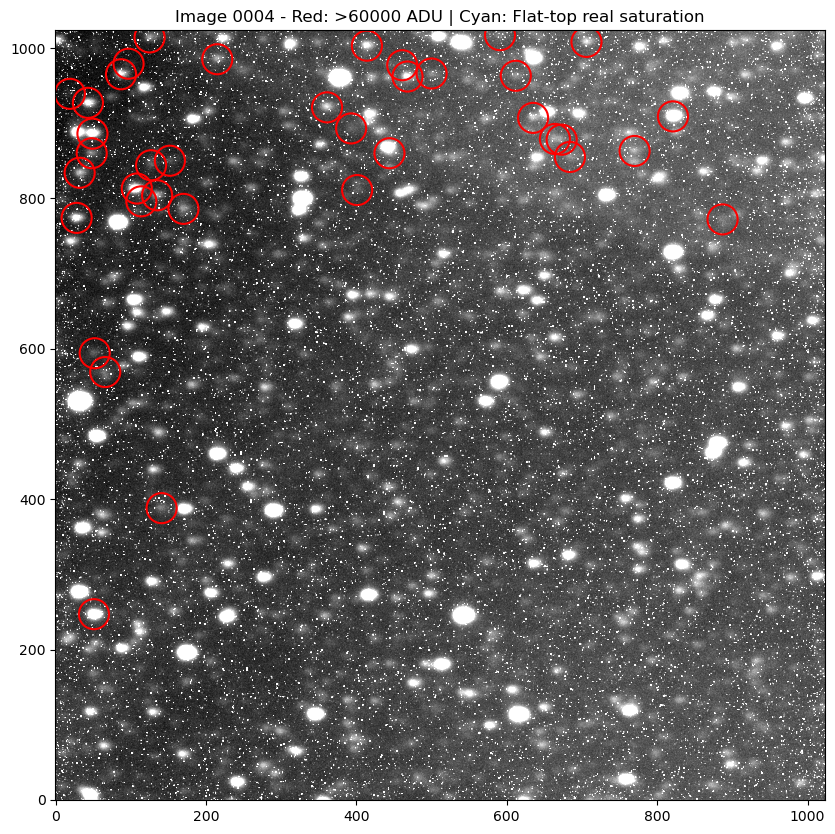

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS
from photutils.aperture import CircularAperture
import pandas as pd
from pathlib import Path

# === CONFIG ===
fits_path = Path('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits')
catalog_path = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/OGLE-2024-BLG-0034/OGLE-2024-BLG-0034_phot_cat.csv"

sat_threshold = 60000
stamp_size = 15

# === LOAD IMAGE + WCS ===
with fits.open(fits_path) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

wcs = WCS(header)

# === LOAD CATALOG ===
catalog = pd.read_csv(catalog_path)

# Convert RA/DEC to pixel coordinates
x_pix, y_pix = wcs.all_world2pix(catalog['RA'].values,
                                 catalog['DEC'].values, 0)

catalog['x'] = x_pix
catalog['y'] = y_pix

# Keep only stars inside image
mask_in = (
    (catalog['x'] > stamp_size) &
    (catalog['x'] < data.shape[1] - stamp_size) &
    (catalog['y'] > stamp_size) &
    (catalog['y'] < data.shape[0] - stamp_size)
)

#catalog = catalog[mask_in]

suspected_sat = []
real_sat = []

# === Saturation diagnostic ===
for i, row in catalog.iterrows():
    try:
        x = int(row['x'])
        y = int(row['y'])

        stamp = data[x-stamp_size:x+stamp_size,y-stamp_size:y+stamp_size]
              #      x-stamp_size:x+stamp_size]

        peak = np.nanmax(stamp)

        if peak > sat_threshold:
            suspected_sat.append((x, y))

            # check flat-top
            n_max = np.sum(stamp == peak)
            if n_max > 3:
                real_sat.append((x, y))
    except Exception as e:
        print(stamp)
        print(f"Error processing star at index {i}: {e}")

print("Stars with peak >60000 ADU:", len(suspected_sat))
print("Stars with real flat-top saturation:", len(real_sat))

# === PLOT ===
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data)

plt.figure(figsize=(10,10))
plt.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)

if suspected_sat:
    ap1 = CircularAperture(suspected_sat, r=20)
    ap1.plot(color='red', lw=1.5)

if real_sat:
    ap2 = CircularAperture(real_sat, r=20)
    ap2.plot(color='cyan', lw=2)

plt.title("Image 0004 - Red: >60000 ADU | Cyan: Flat-top real saturation")
plt.show()

In [ ]:
row

RA            266.062545
DEC           -39.194419
mag            15.670634
BPmag          16.723068
RPmag          14.662246
e_Gmag          0.002785
e_BPmag         0.004016
e_RPmag         0.004034
color           2.060822
V              16.437949
I              14.529888
color_err       0.005692
V_err           0.046125
I_err           0.049677
catalog            Gaia3
x             289.598051
y            1056.882114
Name: 0, dtype: object

In [ ]:

from astropy.io import fits

filename = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/OGLE-2024-BLG-0034_i_comb.fits"

with fits.open(filename) as hdul:
    header = hdul[0].header   # Header del HDU primario
    data = hdul[0].data       # Datos de la imagen (array)
for key in header:
    print(f"{key}   {header[key]}")


SIMPLE   True
BITPIX   -64
NAXIS   2
NAXIS1   1024
NAXIS2   1024
CCDSIZE   [1:1024,1:1024]
CCDSUM   1 1
PIXSIZE1   24.0
PIXSIZE2   24.0
ADCRATE   
GAIN   2.2
RDNOISE   15
CAMTEM   -10.0
EXPTIME   300.0
DATE   2025-06-15T00:18:59
OBSERVAT   CASLEO
TELESCOP   HSH
DATE-OBS   2025-06-15T03:07:49.680000
TIME-OBS   03:07:50.478000
UT   03:07:50.478000
ST   16:05:21.177777
HA   -01:34:31.6
RA   17:45:55.4
DEC   -39:07:13.1
EQUINOX   2000.0
MJD-OBS   60841.13043611111
OBJ_RA   266.04333
OBJ_DEC   -39.11322
ZD   20.5
AIRMASS   1.077777777777778
RA2000   17:44:09.6
DEC2000   -39:06:39.8
DOME-AZ   312.1
IMAGETYP   object
OBJECT   OGLE-2024-BLG-0034
INSTRUME   Direct CCD
INSTRMOD   
OBSERVER   Makler
OPTELE   
COMMENT   = ' '
PROG-ID   HSH-2025A-05
DETECTOR   STL-1001E
PIXSCALE   0.53
FILTER01   (5) I
FILTER02   (6) Free
FILENAME   /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0006_wcs.fits
FILTERS   I
OBJ_STAT   OK
CALIBZ   subtracted bias
BU

In [ ]:
ds[ds["FILENAME"]==calib[0].name]["OBJ_IN"]

384    NaN
Name: OBJ_IN, dtype: object

In [ ]:
ds.loc[(ds["OBJ_IN"]==True,"FILENAME"]

459           FBOGLE-2024-BLG-0034i0001_wcs_trans.fits
460    FBOGLE-2024-BLG-0034i0001_wcs_trans_scaled.fits
461           FBOGLE-2024-BLG-0034i0002_wcs_trans.fits
462    FBOGLE-2024-BLG-0034i0002_wcs_trans_scaled.fits
463           FBOGLE-2024-BLG-0034i0003_wcs_trans.fits
                            ...                       
524           FBOGLE-2024-BLG-0034i0035_wcs_trans.fits
525    FBOGLE-2024-BLG-0034i0035_wcs_trans_scaled.fits
526           FBOGLE-2024-BLG-0034i0036_wcs_trans.fits
527    FBOGLE-2024-BLG-0034i0036_wcs_trans_scaled.fits
528                     OGLE-2024-BLG-0034_i_comb.fits
Name: FILENAME, Length: 70, dtype: object

In [ ]:
36/2

18.0

In [ ]:
# Debug: imprimir info crítica antes de la fotometría
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
i = fits_dir+"/OGLE-2024-BLG-0034_v_comb.fits"
print("\n=== DEBUG: Pre-aperture photometry ===")
print("Current file being processed:", i)  # 'i' es el path de la imagen en el loop

try:
    with fits.open(i) as hdul:
        hdr = hdul[0].header
        data = hdul[0].data
        print("Image shape (data array):", data.shape if data is not None else "No data")
        print("Data type:", data.dtype if data is not None else "None")
        print("Min / Max / Mean pixel value:", 
              np.min(data), np.max(data), np.mean(data) if data is not None else "N/A")
        
        wcs_obj = WCS(hdr)
        print("WCS object valid?", wcs_obj.pixel_n_dim == 2)
        print("WCS:", wcs_obj)
        
        # Posiciones del target (AutoPhOT las usa de aquí o del input)
        print("Target RA/DEC from autophot_input:", 
              autophot_input.get('target_ra'), autophot_input.get('target_dec'))
        print("From header (if present):")
        print("  OBJ_RA / OBJ_DEC:", hdr.get('OBJ_RA'), hdr.get('OBJ_DEC'))
        print("  RA2000 / DEC2000:", hdr.get('RA2000'), hdr.get('DEC2000'))
        print("  CRVAL1 / CRVAL2 (reference pixel):", hdr.get('CRVAL1'), hdr.get('CRVAL2'))
        
        # Chequeo si el target cae dentro de la imagen
        if 'target_ra' in autophot_input and 'target_dec' in autophot_input:
            try:
                pix_x, pix_y = wcs_obj.all_world2pix(
                    autophot_input['target_ra']*15, autophot_input['target_dec'], 0
                )
                print(f"Target pixel position (x,y): {pix_x:.2f}, {pix_y:.2f}")
                if 0 <= pix_x < data.shape[1] and 0 <= pix_y < data.shape[0]:
                    print("→ Target está DENTRO del FOV")
                    print("Valor en el pixel del target:", data[int(pix_y), int(pix_x)])
                else:
                    print("→ Target FUERA del FOV o en borde → posible causa del fallo")
            except Exception as e:
                print("Error proyectando target con WCS:", str(e))
except Exception as e:
    print("Error cargando header/imagen para debug:", str(e))

print("=====================================\n")


=== DEBUG: Pre-aperture photometry ===
Current file being processed: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20240314/OGLE-2024-BLG-0034/phot/OGLE-2024-BLG-0034_v_comb.fits
Image shape (data array): (1024, 1024)
Data type: >f8
Min / Max / Mean pixel value: 476.8575174607387 12366.061400658551 589.217485859812
WCS object valid? True
WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 266.042423556  -39.1475733313  
CRPIX : 401.39899826  763.355239868  
CD1_1 CD1_2  : -0.000155236437064  -7.4666251735899e-07  
CD2_1 CD2_2  : 7.6163446755e-07  -0.000155441121549  
NAXIS : 1024  1024
Target RA/DEC from autophot_input: 17.736222 -39.11322
From header (if present):
  OBJ_RA / OBJ_DEC: 266.04333 -39.11322
  RA2000 / DEC2000: 17:44:10.5 -39:06:52.2
  CRVAL1 / CRVAL2 (reference pixel): 266.042423556 -39.1475733313
Target pixel position (x,y): 396.93, 541.33
→ Target está DENTRO del FOV
Valor en el pixel del target: 613.772931

In [ ]:
dataset["all"]

[PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0001.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0002.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0003.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0004.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0005.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0006.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0007.fit'),
 PosixPath('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250603/BOGLE-2024-BLG-0034i0008.fit'),
 PosixPa

In [ ]:
import subprocess
import os
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from pathlib import Path
from shutil import copyfile
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.visualization.stretch import LogStretch


import matplotlib.pyplot as plt

# =====================================================
# Always create valid default SExtractor files
# =====================================================

def ensure_sextractor_files(outdir: Path, custom_params=None, custom_conv=None):
    outdir.mkdir(exist_ok=True)

    param_file = outdir / "default.param"
    sex_file   = outdir / "default.sex"
    conv_file  = outdir / "default.conv"

    # ---------------- default.param (mismo, no cambia para tests) ----------------
    param_file.write_text(
        "NUMBER\n"
        "X_IMAGE\n"
        "Y_IMAGE\n"
        "FLUX_AUTO\n"
        "FLUXERR_AUTO\n"
        "MAG_AUTO\n"
        "MAGERR_AUTO\n"
        "FWHM_IMAGE\n"
        "ELLIPTICITY\n"
        "THETA_IMAGE\n"
        "FLAGS\n"
        "SNR_WIN\n"
        "FLUX_APER(1)\n"          
        "FLUXERR_APER(1)\n"
    )

    # ---------------- default.conv (permite custom) ----------------
    sextractor_share = Path("/home/knowogrodski/miniconda3/envs/hsh_images/share/sextractor")
    official_conv = sextractor_share / "default.conv"

    if custom_conv:
        conv_file.write_text(custom_conv)
        print("Usando conv customizado")
    elif official_conv.exists():
        copyfile(official_conv, conv_file)
    else:
        conv_file.write_text("""CONV NORM
# 3x3 Gaussian-like convolution mask (standard for star detection)
3 3
1 2 1
2 4 2
1 2 1
""")

    # ---------------- default.sex (permite custom_params como dict) ----------------
    default_settings = (
        "CATALOG_TYPE       ASCII_HEAD\n"
        "DETECT_TYPE        CCD\n"
        "DETECT_MINAREA     5\n"
        "DETECT_THRESH      1.5\n"
        "ANALYSIS_THRESH    1.5\n"
        "DEBLEND_NTHRESH    32\n"
        "DEBLEND_MINCONT    0.005\n"
        "CLEAN              Y\n"
        "CLEAN_PARAM        1.0\n"
        "PHOT_APERTURES     3,5,8\n"           # multiple apertures for robustness
        "PHOT_AUTOPARAMS    2.5,3.5\n"
        "PHOT_FLUXFRAC      0.5\n"
        "SATUR_LEVEL        50000\n"
        "MAG_ZEROPOINT      25.0\n"
        "GAIN               1.0\n"
        "PIXEL_SCALE        1.0\n"
        "SEEING_FWHM        2.0\n"
        "BACK_SIZE          64\n"
        "BACK_FILTERSIZE    3\n"
        "CHECKIMAGE_TYPE    NONE\n"
        "MEMORY_OBJSTACK    3000\n"
        "MEMORY_PIXSTACK    300000\n"
        "MEMORY_BUFSIZE     1024\n"
        "VERBOSE_TYPE       QUIET\n"           # change to NORMAL for more info
    )

    if custom_params:
        settings = default_settings.splitlines()
        for key, value in custom_params.items():
            for i, line in enumerate(settings):
                if line.strip().startswith(key):
                    settings[i] = f"{key} {value}"
                    break
            else:
                settings.append(f"{key} {value}")
        sex_file.write_text("\n".join(settings))
        print("Configuración customizada aplicada a default.sex")
    else:
        sex_file.write_text(default_settings)


# =====================================================
# Run SExtractor
# =====================================================

def run_sextractor(fits_path: Path, outdir: Path, test_name="default", 
                   custom_params=None, custom_conv=None, overwrite=False) -> Path:
    ensure_sextractor_files(outdir, custom_params, custom_conv)

    sex_file   = outdir / "default.sex"
    param_file = outdir / "default.param"
    conv_file  = outdir / "default.conv"
    cat_path   = outdir / f"{fits_path.stem}_cat_{test_name}.txt"

    if cat_path.exists() and not overwrite:
        print(f"         Omitiendo: {cat_path} ya existe.")
        return cat_path

    cmd = [
        "sex", str(fits_path),
        "-c", str(sex_file),
        "-CATALOG_NAME", str(cat_path),
        "-PARAMETERS_NAME", str(param_file),
        "-FILTER", "Y",
        "-FILTER_NAME", str(conv_file),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("\n===== Command executed =====")
        print(" ".join(cmd))
        print("\n===== Content of default.conv =====")
        print(conv_file.read_text())
        print("\n===== Content of default.sex =====")
        print(sex_file.read_text())
        print("\n===== SExtractor STDOUT =====")
        print(result.stdout)
        print("\n===== SExtractor STDERR =====")
        print(result.stderr)
        raise RuntimeError("SExtractor failed")

    print(f"      ✓ Catálogo generado: {cat_path}")
    return cat_path

# =====================================================
# Función para testear múltiples configs de SExtractor
# =====================================================

def test_sextractor_configs(fits_path: Path, outdir: Path, astrom_cat_path: Path,
                            configs, max_sep_arcsec=1.0, plot=True):
    """
    Testea múltiples configuraciones de SExtractor:
    - Corre SExtractor con cada config
    - Calcula matches con catálogo astrométrico
    - Plotea imagen con fuentes matched (verde) y no matched (rojo)
    - Imprime stats (n_detected, n_matched, RMS residuales)
    
    configs: lista de dicts con custom_params, e.g.:
    [{"DETECT_THRESH": 1.2, "SEEING_FWHM": 1.8}, ...]
    """
    results = {}

    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()
        w = WCS(hdul[0].header)

    norm = ImageNormalize(data, interval=ZScaleInterval())

    # Leer catálogo astrométrico
    df_astrom = pd.read_csv(astrom_cat_path)
    coord_ref = SkyCoord(ra=df_astrom["RA"].values * u.deg,
                         dec=df_astrom["DEC"].values * u.deg, frame='icrs')

    for i, config in enumerate(configs):
        test_name = f"test_{i+1}"
        print(f"\n→ Test {test_name}: {config}")

        cat_path = run_sextractor(fits_path, outdir, test_name=test_name,
                                  custom_params=config, overwrite=True)

        # Leer catálogo generado
        df_sex = pd.read_csv(cat_path, delim_whitespace=True, comment="#", header=None)
        df_sex.columns = column_names[:df_sex.shape[1]]

        good = df_sex[(df_sex["FLAGS"] == 0) & (df_sex["FWHM_IMAGE"] > 0)].copy()

        # Convertir a RA/DEC
        ra_sex, dec_sex = w.all_pix2world(good["X_IMAGE"], good["Y_IMAGE"], 0)
        coord_sex = SkyCoord(ra=ra_sex * u.deg, dec=dec_sex * u.deg, frame='icrs')

        # Matching
        idx, sep, _ = coord_sex.match_to_catalog_sky(coord_ref)
        has_match = sep < max_sep_arcsec * u.arcsec

        matched = good[has_match].copy()
        unmatched = good[~has_match].copy()

        n_detected = len(good)
        n_matched = len(matched)

        print(f"   Detectadas: {n_detected}")
        print(f"   Matched < {max_sep_arcsec} arcsec: {n_matched} ({n_matched/n_detected*100:.1f}%)")

        if n_matched > 0:
            ra_diff = (coord_sex.ra - coord_ref[idx].ra).to(u.arcsec).value[has_match]
            dec_diff = (coord_sex.dec - coord_ref[idx].dec).to(u.arcsec).value[has_match]
            rms_ra = np.std(ra_diff)
            rms_dec = np.std(dec_diff)
            print(f"   RMS ΔRA/ΔDEC: {rms_ra:.3f}/{rms_dec:.3f} arcsec")
            print(f"   Bias median ΔRA/ΔDEC: {np.median(ra_diff):.3f}/{np.median(dec_diff):.3f} arcsec")
        else:
            rms_ra, rms_dec = np.nan, np.nan

        results[test_name] = {
            "cat_path": cat_path,
            "n_detected": n_detected,
            "n_matched": n_matched,
            "rms_ra": rms_ra,
            "rms_dec": rms_dec,
        }

        if plot:
            fig, ax = plt.subplots(figsize=(10, 10))
            ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
            ax.set_title(f"{fits_path.name} - Test {test_name}\nMatched < {max_sep_arcsec} arcsec")
            ax.axis('off')

            # Fuentes SExtractor matched → verde
            if not matched.empty:
                ax.scatter(matched["X_IMAGE"], matched["Y_IMAGE"],
                           s=60, facecolor='none', edgecolor='lime', lw=1.4,
                           label=f"Matched ({len(matched)})")

            # Fuentes SExtractor sin match → rojo
            if not unmatched.empty:
                ax.scatter(unmatched["X_IMAGE"], unmatched["Y_IMAGE"],
                           s=90, facecolor='none', edgecolor='red', lw=2.0, alpha=0.9,
                           label=f"Sin match ({len(unmatched)})")

            ax.legend(loc='upper right', fontsize=10, framealpha=0.85)

            plt.tight_layout()
            plot_path = outdir / f"{fits_path.stem}_test_{test_name}.png"
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"   Plot guardado: {plot_path}")

    # Resumen de tests
    print("\nResumen de tests:")
    for test, res in results.items():
        print(f"{test}: Detectadas={res['n_detected']}, Matched={res['n_matched']}, RMS RA/DEC={res['rms_ra']:.3f}/{res['rms_dec']:.3f}")

    return results

# =====================================================
# Ejemplo de uso para tests
# =====================================================

# Configs a testear (ajusta según tu instrumental)
test_configs = [
    {"DETECT_THRESH": 1.2, "ANALYSIS_THRESH": 1.2, "DETECT_MINAREA": 4, "SEEING_FWHM": 1.8, "BACK_SIZE": 48},   # Baja thresh, pequeño minarea
    {"DETECT_THRESH": 1.5, "ANALYSIS_THRESH": 1.5, "DETECT_MINAREA": 6, "SEEING_FWHM": 2.5, "BACK_SIZE": 64},   # Default-like
    {"DETECT_THRESH": 1.8, "ANALYSIS_THRESH": 1.8, "DETECT_MINAREA": 8, "SEEING_FWHM": 3.0, "BACK_SIZE": 96},   # Más conservador, alto thresh
    {"DETECT_THRESH": 1.5, "ANALYSIS_THRESH": 1.5, "DETECT_MINAREA": 5, "DEBLEND_MINCONT": 0.002, "BACK_FILTERSIZE": 5},  # Deblend más agresivo
    # Agrega más: e.g. custom_conv = "CONV NORM\n5 5\n1 2 3 2 1\n2 4 6 4 2\n3 6 9 6 3\n2 4 6 4 2\n1 2 3 2 1\n"
]

# Llama la función de test
results = test_sextractor_configs(
    fits_path = fits_path,  # tu imagen problemática
    outdir = night_dir / "qc_outputs",
    astrom_cat_path = object_path / objname / f"{objname}_astro_cat.csv",
    configs = test_configs,
    max_sep_arcsec = 1.0,
    plot = True
)

# Analiza results para ver cuál config da mejor RMS / más matches sin falsos


→ Test test_1: {'DETECT_THRESH': 1.2, 'ANALYSIS_THRESH': 1.2, 'DETECT_MINAREA': 4, 'SEEING_FWHM': 1.8, 'BACK_SIZE': 48}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_1.txt
   Detectadas: 786
   Matched < 1.0 arcsec: 259 (33.0%)
   RMS ΔRA/ΔDEC: 0.337/0.348 arcsec
   Bias median ΔRA/ΔDEC: -0.579/-0.461 arcsec
   Plot guardado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_test_test_1.png

→ Test test_2: {'DETECT_THRESH': 1.5, 'ANALYSIS_THRESH': 1.5, 'DETECT_MINAREA': 6, 'SEEING_FWHM': 2.5, 'BACK_SIZE': 64}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_2.txt
   Detectadas: 505
   Matched < 

In [ ]:
import re

qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for i in range(len(sex_cat)):
    path = sex_cat[i]
    # try to extract column names from the comment header (if present)
    with open(path, "r") as fh:
        header_text = "".join([ln for ln in fh if ln.startswith("#")])
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # read whitespace-separated SExtractor catalog; ignore comment lines
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                        names=col_names if col_names else None)

    # example: get 4th row values (same as .iloc[3].values)
    df_sex

    %matplotlib inline
    # buscar imagen correspondiente al catálogo (el nombre quitando "_cat.txt")
    from astropy.io import fits
    from astropy.visualization import ZScaleInterval, ImageNormalize
    import matplotlib.pyplot as plt

    image_base = path.name.replace("_cat.txt", ".fits")  # ej. 'FBOGLE-..._wcs'


    im_path = night_dir/image_base
    with fits.open(im_path) as hdul:
        data = hdul[0].data
    if data is None:
        print(f"No hay datos en {im_path}")
    else:
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]
        norm = ImageNormalize(data, interval=ZScaleInterval())
        plt.figure(figsize=(8, 8))
        plt.imshow(data, origin='lower', cmap='gray', norm=norm)
        # si hay columnas X_IMAGE/Y_IMAGE, dibujar fuentes
        if {'X_IMAGE', 'Y_IMAGE'}.issubset(df_sex.columns):
            plt.scatter(df_sex['X_IMAGE'], df_sex['Y_IMAGE'],
                        s=15, edgecolor='red', facecolor='none', linewidth=0.7)
        plt.title(f"Image: {im_path.name}")
        plt.colorbar(label='counts')
        plt.show()
        df_sex["ELLIPTICITY"].hist()
        med=df_sex["ELLIPTICITY"].median()
        mea = df_sex["ELLIPTICITY"].mean()
        plt.axvline(df_sex["ELLIPTICITY"].median(), color="r", label = f"median {med}")
        plt.axvline(df_sex["ELLIPTICITY"].mean(),color="k", label = f"mean {mea}")
        st = df_sex["ELLIPTICITY"].std()
        plt.title(f"ellipticity, std={st}")
        plt.legend()
        plt.show()
        df_sex[df_sex["FWHM_IMAGE"]>0]["FWHM_IMAGE"].hist()
        plt.title("fwhm")
        plt.show()

In [ ]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Suponiendo que night_dir ya está definido
qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for path in sex_cat:
    # ── Leer encabezado para nombres de columnas ─────────────────────────
    with open(path, "r") as fh:
        header_text = "".join(ln for ln in fh if ln.startswith("#"))
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # Leer catálogo SExtractor
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                         names=col_names if col_names else None)

    if df_sex.empty:
        print(f"Catálogo vacío: {path.name}")
        continue

    # ── Buscar imagen correspondiente ─────────────────────────────────────
    image_base = path.name.replace("_cat.txt", ".fits")
    im_path = night_dir / image_base

    if not im_path.exists():
        print(f"No se encontró imagen: {im_path}")
        continue

    with fits.open(im_path) as hdul:
        data = hdul[0].data
        if data is None:
            print(f"No hay datos en {im_path}")
            continue
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]

    # Normalización
    norm = ImageNormalize(data, interval=ZScaleInterval())

    # ── Figura ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
    ax.set_title(f"{im_path.name}", fontsize=13)
    ax.axis('off')

    # ── Dibujar fuentes con colores según FWHM ────────────────────────────
    if {'X_IMAGE', 'Y_IMAGE', 'FWHM_IMAGE'}.issubset(df_sex.columns):
        # Fuentes válidas (FWHM > 0) → blanco
        valid = df_sex[df_sex["FWHM_IMAGE"] > 0]
        ax.scatter(valid['X_IMAGE'], valid['Y_IMAGE'],
                   s=18, edgecolor='white', facecolor='none',
                   linewidth=1.1, label=f'Valid FWHM > 0 ({len(valid)})')

        # Fuentes problemáticas (FWHM ≤ 0) → rojo
        invalid = df_sex[df_sex["FWHM_IMAGE"] <= 0]
        if not invalid.empty:
            ax.scatter(invalid['X_IMAGE'], invalid['Y_IMAGE'],
                       s=22, edgecolor='red', facecolor='none',
                       linewidth=1.4, alpha=0.9,
                       label=f'Bad FWHM ≤ 0 ({len(invalid)})')

        ax.legend(loc='upper right', fontsize=9, framealpha=0.85)

    # Colorbar
    plt.colorbar(ax.imshow(data, origin='lower', cmap='gray_r', norm=norm),
                 ax=ax, fraction=0.046, pad=0.04, label='counts')

    plt.tight_layout()
    plt.show()
    break

In [ ]:
%matplotlib inline
srcs = df_sex[df_sex["FWHM_IMAGE"]>0]
plt.plot(srcs["THETA_IMAGE"].values, srcs["ELLIPTICITY"].values, ".")
plt.show()

In [ ]:
source = df_sex[df_sex['NUMBER'] == 103]
if source.empty:
    print("No se encontró la fuente")
else:
    x = source['X_IMAGE'].iloc[0]
    y = source['Y_IMAGE'].iloc[0]
    print(f"Fuente encontrada → X={x:.1f}, Y={y:.1f}, FWHM={source['FWHM_IMAGE'].iloc[0]:.2f}")

    # ── Parámetros del zoom ──────────────────────────────────────────
    zoom_size = 60          # radio en píxeles (tamaño total = 2*zoom_size)
    cutout_half = zoom_size // 2

    # Leer la imagen
    with fits.open(im_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()

    # Recortar (con protección por bordes)
    x_int, y_int = int(x), int(y)
    x_min = max(0, x_int - cutout_half)
    x_max = min(data.shape[1], x_int + cutout_half + 1)
    y_min = max(0, y_int - cutout_half)
    y_max = min(data.shape[0], y_int + cutout_half + 1)

    cutout = data[y_min:y_max, x_min:x_max]

    # ── Graficar el zoom ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))

    norm = ImageNormalize(data, interval=ZScaleInterval())
    ax.imshow(cutout, origin='lower', cmap='gray', norm=norm)

    # Marcar el centro exacto (la posición real de la fuente)
    center_x = x - x_min
    center_y = y - y_min
    ax.scatter(center_x, center_y, s=200, marker='+', color='lime', linewidth=2.5,
               label=f"Centro fuente (X={x:.1f}, Y={y:.1f})")

    ax.set_title(f"Zoom fuente (size ≈ {zoom_size*2}px) | FWHM {source['FWHM_IMAGE'].iloc[0]:.2f}")
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlabel("píxeles relativos")
    ax.set_ylabel("píxeles relativos")

    # Opcional: agregar círculo con tamaño FWHM aproximado
    from matplotlib.patches import Circle
    fwhm = source['FWHM_IMAGE'].iloc[0]
    if fwhm > 0:
        circle = Circle((center_x, center_y), radius=fwhm/2, color='cyan', 
                        fill=False,
                        linewidth=1.8, linestyle='--', alpha=0.8,
                        label=f"FWHM/2 ≈ {fwhm/2:.1f} px")
        ax.add_patch(circle)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
df_sex[df_sex["FWHM_IMAGE"]<0]

In [ ]:
good_images

In [ ]:
df_sex